# Homework 8: Predicting Power Loads with LSTM Networks

## Due: Midnight on **Sunday, March 22nd** (with a 2-hour grace period)  
**Worth:** 85 points

In this assignment, you’ll build and analyze recurrent neural-network models to forecast hourly power demand, using the direct method, and comparing it with autoregressive methods.

**Direct (Non-Autoregressive) Time Series Prediction:**

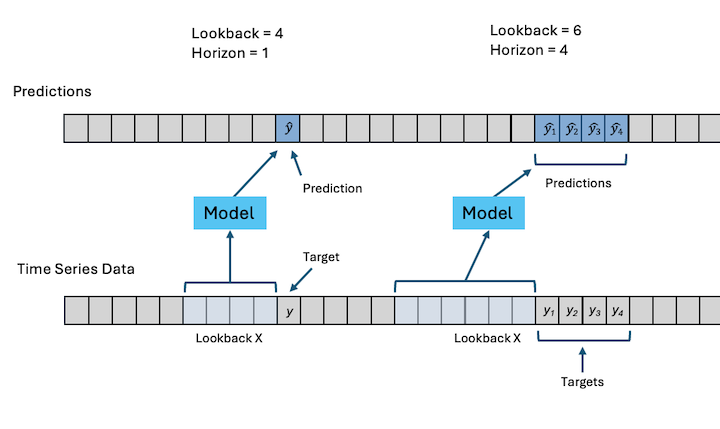


**What we'll do in this homework**

Starting from a working LSTM baseline, you’ll experiment with how the **direct** forcasting models performs, and investigate how **lookback**, **forecast horizon**, and **architecture** affect predictive accuracy and generalization.  
You’ll also explore an **autoregressive** variant, where the model rolls forward one hour at a time—an approach that often highlights how small errors can accumulate.

You’ll complete three problems:

* **Problem 1 — Exploring Lookback and Horizon:**  
  Adjust how far back the model looks and how far ahead it predicts, and examine how these design choices influence MAE/RMSE.

* **Problem 2 — Architectural Tweaks:**  
  Modify the LSTM architecture by deepening the network, stacking layers, or adding a bidirectional layer, and evaluate the effect on validation performance.

* **Problem 3 — Autoregressive Forecasting (ChatGPT Discussion):**  
  Work interactively with ChatGPT to design a one-step-at-a-time autoregressive version of your model, and discuss how it compares to your direct multi-output model.



For each problem, you'll report your best validation metrics, display the learning-curve plots, and briefly reflect on what you learned from the experiment.

There are 5 graded problems, worth 17 points each. 

## Setup and Data Loading


In [17]:
# ---------- Standard Library ----------
import os
import time
import math
import random
from pathlib import Path
from collections import Counter

# Environment (set BEFORE importing TensorFlow)
os.environ["PYTHONHASHSEED"] = "0"        # Disable hash randomization
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # Deterministic TF ops where possible
os.environ["TF_CUDNN_DETERMINISM"] = "1"  # Deterministic CuDNN (if GPU)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Suppress TF INFO/WARNING logs

# ---------- Third-Party (General) ----------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,StratifiedShuffleSplit, ShuffleSplit
import kagglehub

# ---------- TensorFlow / Keras ----------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers, initializers, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.layers import GlobalMaxPooling1D, SpatialDropout1D, Bidirectional
# Layers (vision)
from tensorflow.keras.layers import (
    Input, Conv2D,Conv1D, SeparableConv2D, MaxPooling2D, GlobalAveragePooling2D,
    GlobalMaxPooling2D, BatchNormalization, ReLU, Flatten, Dense, Dropout
)

# Preprocessing (vision)
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ---------- (Optional) NLP-related imports ----------
# If not doing NLP, you can safely remove this block.
from tensorflow.keras.layers import (
    Embedding, GlobalAveragePooling1D, LSTM, GRU, SpatialDropout1D, Bidirectional, Lambda
)
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.datasets import imdb  # uncomment only if needed

# ---------- Reproducibility ----------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)  # covers TF, Python, and NumPy RNGs

# ---------- Convenience ----------
he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

def format_hms(seconds: float) -> str:
    """Format seconds as H:MM:SS."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# Example:
# start = time.time()
# ... your code ...
# print("Elapsed:", format_hms(time.time() - start))


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Single global registry (scaled units)
results = {}   # title -> dict with selected-epoch metrics and (optional) diagnostics

def plot_learning_curves_scaled(
    history,
    title="Learning Curves — MAE & RMSE (scaled)",
    verbose=True,
    record_globals=False,   # set True if you also want global minima as diagnostics
):
    """
    Plot MAE/RMSE directly from Keras History (scaled units).
    Select the epoch by min `val_loss` and record all metrics at that epoch.
    """
    H = history.history if hasattr(history, "history") else history
    if not isinstance(H, dict):
        raise ValueError("history must be a Keras History or a dict")

    if "loss" not in H:
        raise ValueError("History must contain 'loss' (MSE).")

    has_val_loss = "val_loss" in H and len(H["val_loss"]) > 0

    loss     = np.asarray(H["loss"], dtype=float)
    val_loss = np.asarray(H["val_loss"], dtype=float) if has_val_loss else None

    mae      = np.asarray(H["mae"], dtype=float)      if "mae"      in H else None
    val_mae  = np.asarray(H["val_mae"], dtype=float)  if "val_mae"  in H else None
    rmse     = np.asarray(H["rmse"], dtype=float)     if "rmse"     in H else np.sqrt(loss)
    val_rmse = np.asarray(H["val_rmse"], dtype=float) if "val_rmse" in H else (np.sqrt(val_loss) if has_val_loss else None)

    epochs = np.arange(1, len(loss) + 1)

    # ----- Select epoch by min val_loss (or last if no validation) -----
    if has_val_loss:
        sel_idx = int(np.argmin(val_loss))
        sel_note = "min val_loss"
    else:
        sel_idx = len(loss) - 1
        sel_note = "last epoch (no validation)"

    # Values at the selected epoch
    sel = {
        "epoch": sel_idx + 1,
        "selected_by": sel_note,
        "loss": float(loss[sel_idx]),
        "val_loss": float(val_loss[sel_idx]) if has_val_loss else np.nan,
        "mae": float(mae[sel_idx]) if mae is not None else np.nan,
        "val_mae": float(val_mae[sel_idx]) if val_mae is not None and has_val_loss else np.nan,
        "rmse": float(rmse[sel_idx]) if rmse is not None else (float(np.sqrt(loss[sel_idx])) if np.isfinite(loss[sel_idx]) else np.nan),
        "val_rmse": (
            float(val_rmse[sel_idx]) if (val_rmse is not None and has_val_loss)
            else (float(np.sqrt(val_loss[sel_idx])) if has_val_loss and np.isfinite(val_loss[sel_idx]) else np.nan)
        ),
    }

    # Optional: global minima diagnostics
    globs = {}
    if record_globals:
        if val_rmse is not None:
            i = int(np.argmin(val_rmse))
            globs.update(min_val_rmse=float(val_rmse[i]), epoch_min_val_rmse=i+1)
        if val_mae is not None:
            j = int(np.argmin(val_mae))
            globs.update(min_val_mae=float(val_mae[j]), epoch_min_val_mae=j+1)

    # ----- Plot (scaled units) -----
    fig, ax = plt.subplots(figsize=(8, 5))
    if rmse is not None:
        ax.plot(epochs, rmse, label="train RMSE (scaled)")
    if val_rmse is not None:
        ax.plot(epochs, val_rmse, label="val RMSE (scaled)")
    if mae is not None:
        ax.plot(epochs, mae, linestyle="--", label="train MAE (scaled)")
    if val_mae is not None:
        ax.plot(epochs, val_mae, linestyle="--", label="val MAE (scaled)")

    # Mark the selected epoch on validation curves
    if has_val_loss and (val_rmse is not None or val_mae is not None):
        if val_rmse is not None:
            ax.scatter(sel["epoch"], sel["val_rmse"], marker="x", s=70,
                       label=f"val RMSE @ {sel_note} = {sel['val_rmse']:.3g} (ep {sel['epoch']})")
        if val_mae is not None:
            ax.scatter(sel["epoch"], sel["val_mae"], marker="o", s=50,
                       label=f"val MAE @ {sel_note} = {sel['val_mae']:.3g} (ep {sel['epoch']})")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Error (scaled units)")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ----- Record (scaled) -----
    final = {
        "selected_epoch": sel["epoch"],
        "selected_by": sel["selected_by"],
        "val_mae_at_min_valloss": sel["val_mae"],
        "val_rmse_at_min_valloss": sel["val_rmse"],
        "train_mae_at_sel": sel["mae"],
        "train_rmse_at_sel": sel["rmse"],
        # keep last-epoch values if you want them too:
        "final_train_rmse": float(rmse[-1])     if rmse is not None else np.nan,
        "final_val_rmse":   float(val_rmse[-1]) if val_rmse is not None else np.nan,
        "final_train_mae":  float(mae[-1])      if mae is not None else np.nan,
        "final_val_mae":    float(val_mae[-1])  if val_mae is not None else np.nan,
        "units":            "scaled",
    }
    final.update(globs)  # add diagnostics if requested

    if verbose:
        print(f"Selected epoch: {final['selected_epoch']} ({final['selected_by']})")
        print(f"Valid @ sel —  MAE: {final['val_mae_at_min_valloss']:.4g} | RMSE: {final['val_rmse_at_min_valloss']:.4g} (scaled)")
        print(f"Train @ sel —  MAE: {final['train_mae_at_sel']:.4g}  | RMSE: {final['train_rmse_at_sel']:.4g} (scaled)")

    results[title] = final


def print_results(sort_by="val_rmse_at_min_valloss"):
    if not results:
        print("No results recorded yet."); return
    ordering = sorted(results.items(), key=lambda kv: kv[1].get(sort_by, np.inf))
    for name, info in ordering:
        print(f"{name:<35}  val_RMSE@min_val_loss={info.get('val_rmse_at_min_valloss', np.nan):.4g} "
              f"| val_MAE@min_val_loss={info.get('val_mae_at_min_valloss', np.nan):.4g} "
              f"| epoch={info.get('selected_epoch')}  (scaled)")


###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Uses "binary_crossentropy" for binary classification task. 
- Assumes `X_train,y_train,X_val,y_val,X_test,y_test` already defined, accessed here as global variables, or can specify them when calling
    - If you don’t pass X_train, it will look in the global namespace at call time.
    - If you do pass an explicit X_train=..., that value takes priority.
  
>      # uses global X_train, y_train, ...
>      train_and_test(model)
>
>      # uses explicitly passed datasets
>      train_and_test(model, X_train=new_X, y_train=new_y)

In [19]:
import time
import numpy as np
import tensorflow as tf
from sklearn.model_selection import ShuffleSplit, StratifiedShuffleSplit
from tensorflow.keras.callbacks import EarlyStopping

def train_and_test(
    model,
    X_train=None, y_train=None,
    X_val=None,   y_val=None,
    X_test=None,  y_test=None,
    *,
    epochs=50,
    optimizer="Adam",
    lr_schedule=1e-3,
    clipnorm=1.0,
    loss="mse",                         # keep MSE for training
    metrics=("mae", "rmse"),            # track MAE & RMSE in curves
    validation_split=0.2,
    random_state=42,
    title="Learning Curves (MSE loss; MAE & RMSE tracked)",
    batch_size=64,
    use_early_stopping=True,
    patience=5,
    min_delta=1e-4,
    callbacks=None,
    verbose=0,
    return_history=False,
    plot_scaled_curves=True,            # uses plot_learning_curves_scaled if available
):
    """
    Trains with MSE and tracks MAE/RMSE. Selects the epoch by min `val_loss`,
    and reports *all* metrics at that same epoch to avoid cherry-picking.
    Returns (history, test_results, info) if return_history=True else (test_results, info).
    """

    # ---------- Resolve datasets lazily from globals if not provided ----------
    g = globals()
    X_train = X_train if X_train is not None else g.get("X_train")
    y_train = y_train if y_train is not None else g.get("y_train")
    X_val   = X_val   if X_val   is not None else g.get("X_val")
    y_val   = y_val   if y_val   is not None else g.get("y_val")
    X_test  = X_test  if X_test  is not None else g.get("X_test")
    y_test  = y_test  if y_test  is not None else g.get("y_test")

    # ---------- Basic checks ----------
    if X_train is None or y_train is None:
        raise ValueError("Training data (X_train, y_train) not provided or defined globally.")
    if X_test is None or y_test is None:
        raise ValueError("Test data (X_test, y_test) not provided or defined globally.")

    # ---------- If no explicit val provided, optionally create one from training ----------
    made_internal_val = False
    if X_val is None or y_val is None:
        if validation_split and validation_split > 0.0:
            X_tr = np.asarray(X_train)
            y_tr = np.asarray(y_train)
            test_size = float(validation_split)

            def _is_single_label_classification(y):
                try:
                    y = np.asarray(y)
                    return np.issubdtype(y.dtype, np.integer) and (len(np.unique(y)) < max(20, 0.02*len(y)))
                except Exception:
                    return False

            if _is_single_label_classification(y_tr):
                splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
                (train_idx, val_idx), = splitter.split(X_tr, y_tr)
            else:
                splitter = ShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
                (train_idx, val_idx), = splitter.split(np.arange(len(X_tr)))

            X_train, y_train = X_tr[train_idx], y_tr[train_idx]
            X_val,   y_val   = X_tr[val_idx],   y_tr[val_idx]
            made_internal_val = True
        else:
            if use_early_stopping:
                raise ValueError("Early stopping needs validation. Provide (X_val, y_val) or set validation_split > 0.")

    if title:
        print(f"\n{title}\n")

    # ---------- Optimizer ----------
    if isinstance(optimizer, str):
        opt = getattr(tf.keras.optimizers, optimizer)(learning_rate=lr_schedule, clipnorm=clipnorm)
    else:
        opt = optimizer

    # ---------- Metrics ----------
    keras_metrics = []
    for m in metrics:
        if isinstance(m, str):
            key = m.lower()
            if key in ("mae", "meanabsoluteerror"):
                keras_metrics.append(tf.keras.metrics.MeanAbsoluteError(name="mae"))
            elif key in ("rmse", "rootmeansquarederror"):
                keras_metrics.append(tf.keras.metrics.RootMeanSquaredError(name="rmse"))
            elif key in ("mse", "meansquarederror"):
                keras_metrics.append(tf.keras.metrics.MeanSquaredError(name="mse"))
            else:
                keras_metrics.append(m)
        else:
            keras_metrics.append(m)

    model.compile(optimizer=opt, loss=loss, metrics=keras_metrics)

    # ---------- Callbacks ----------
    cb = [] if callbacks is None else list(callbacks)
    if use_early_stopping:
        cb = [EarlyStopping(monitor="val_loss", patience=patience, min_delta=min_delta,
                            restore_best_weights=True, verbose=verbose)] + cb

    # ---------- Fit ----------
    start = time.time()
    fit_kwargs = dict(
        x=X_train, y=y_train,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=verbose,
        shuffle=True,
    )
    if X_val is not None and y_val is not None:
        fit_kwargs["validation_data"] = (X_val, y_val)

    history = model.fit(**fit_kwargs)
    hist = history.history

    # ---------- Select epoch by min val_loss ----------
    if "val_loss" in hist and len(hist["val_loss"]) > 0:
        sel_idx = int(np.argmin(hist["val_loss"]))       # 0-based
        selected_by = "val_loss"
    else:
        # fallback: last epoch if no val set
        sel_idx = len(hist.get("loss", [])) - 1
        selected_by = "loss (no validation)"

    # Gather metrics at selected epoch (scaled units)
    def _get(name):
        v = hist.get(name, None)
        return float(v[sel_idx]) if v is not None and len(v) > sel_idx else float("nan")

    selected = {
        "epoch":         sel_idx + 1,
        "selected_by":   selected_by,
        "loss":          _get("loss"),
        "val_loss":      _get("val_loss"),
        "mae":           _get("mae"),
        "val_mae":       _get("val_mae"),
        "rmse":          _get("rmse") if "rmse" in hist else float(np.sqrt(_get("loss"))) if np.isfinite(_get("loss")) else float("nan"),
        "val_rmse":      _get("val_rmse") if "val_rmse" in hist else float(np.sqrt(_get("val_loss"))) if np.isfinite(_get("val_loss")) else float("nan"),
    }

    # ---------- Evaluate on test set (scaled units) ----------
    test_out = model.evaluate(X_test, y_test, verbose=0)
    metric_names = model.metrics_names
    test_results = dict(zip(metric_names, map(float, np.atleast_1d(test_out))))
    if "loss" in test_results:
        test_results["rmse_from_mse_loss"] = float(np.sqrt(test_results["loss"]))

    elapsed = time.time() - start

    # ---------- Console summary (report everything at selected epoch) ----------
    # print(f"Selected epoch: {selected['epoch']} (by {selected['selected_by']})")
    # print(f"Train @ sel —  LOSS: {selected['loss']:.6f} | MAE: {selected['mae']:.6f} | RMSE: {selected['rmse']:.6f}")
    # if np.isfinite(selected["val_loss"]):
    #     print(f"Valid @ sel —  LOSS: {selected['val_loss']:.6f} | MAE: {selected['val_mae']:.6f} | RMSE: {selected['val_rmse']:.6f}")
    # print("Test  (final weights after ES restore) — " +
    #       " | ".join([f"{k.upper()}: {v:.6f}" for k, v in test_results.items()]) +
    #       f"   (time: {elapsed:.1f}s)")

    # ---------- Optional: plot scaled curves & record to registry ----------
    if plot_scaled_curves and 'plot_learning_curves_scaled' in globals():
        plot_learning_curves_scaled(history, title=title, verbose=verbose)

    info = {
        "made_internal_val": made_internal_val,
        "elapsed_sec": elapsed,
        "selected_epoch": selected["epoch"],
        "selected_by": selected_by,
        "train_at_sel": {"loss": selected["loss"], "mae": selected["mae"], "rmse": selected["rmse"]},
        "val_at_sel":   {"loss": selected["val_loss"], "mae": selected["val_mae"], "rmse": selected["val_rmse"]},
    }

    if return_history:
        return history, test_results, info


### Learning Rate Schedulers

In [20]:
# Must be input as callback in train_and_test(....   , callbacks=[reduce_lr] )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-8,           # Lower bound on the learning rate.
    verbose=0,             # 0: quiet, 1: update messages.
)

### Load and prepare data

Window kept: 2025-01-01 00:00:00  →  2025-05-31 23:00:00  (3624 hours)
Split sizes — train: 2536, val: 543, test: 545


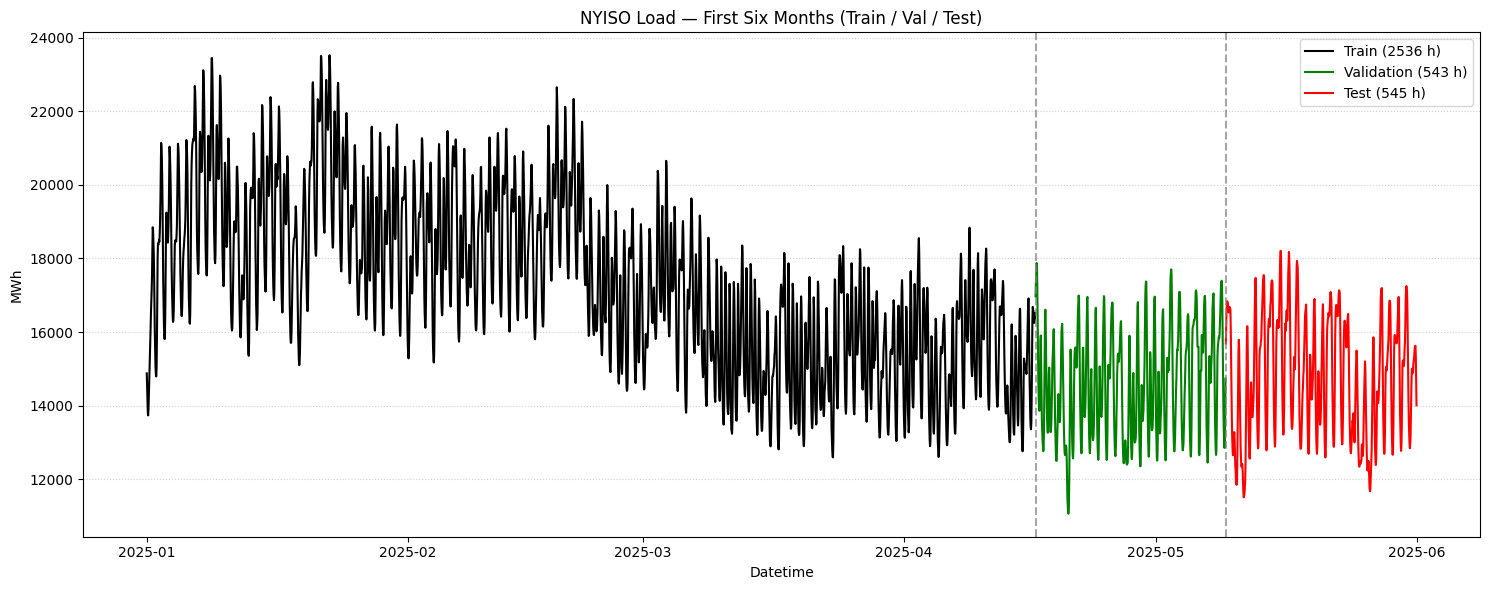


MegaWatts per Hour — First Six Months

Datetime
2025-01-01 00:00:00    14877.0
2025-01-01 01:00:00    14487.0
2025-01-01 02:00:00    14091.0
2025-01-01 03:00:00    13804.0
2025-01-01 04:00:00    13735.0
2025-01-01 05:00:00    13929.0
Freq: h, Name: NYISO_Load, dtype: float64
....
Datetime
2025-05-31 18:00:00    15571.0
2025-05-31 19:00:00    15610.0
2025-05-31 20:00:00    15628.0
2025-05-31 21:00:00    15342.0
2025-05-31 22:00:00    14727.0
2025-05-31 23:00:00    14007.0
Freq: h, Name: NYISO_Load, dtype: float64
Length: 3624 hours


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

# --------------------------
# 0) Load & reshape (Hr1..Hr24 only)
# --------------------------
df = pd.read_csv("https://www.cs.bu.edu/fac/snyder/cs505/Data/nyiso_loads.csv")

# strictly keep Hr1..Hr24 (drop Hr25 if present)
hour_cols = sorted(
    [c for c in df.columns if re.fullmatch(r"Hr\d+", c) and 1 <= int(c[2:]) <= 24],
    key=lambda c: int(c[2:])
)

# wide -> long (1 row per hour)
long_df = df.melt(
    id_vars=["Year", "Month", "Day"],
    value_vars=hour_cols,
    var_name="Hour",
    value_name="Load"
).sort_values(["Year", "Month", "Day", "Hour"], ignore_index=True)

# datetime index
long_df["Datetime"] = (
    pd.to_datetime(long_df[["Year", "Month", "Day"]]) +
    pd.to_timedelta(long_df["Hour"].str.extract(r"(\d+)").astype(int)[0] - 1, unit="h")
)
long_df = long_df.sort_values("Datetime", ignore_index=True)

# series
load_series = pd.Series(long_df["Load"].values, index=long_df["Datetime"], name="NYISO_Load")
load_series.index.name = "Datetime"

# --------------------------
# 1) Keep ONLY the first six months from the series start
# --------------------------
start = load_series.index.min().normalize()
end   = start + pd.DateOffset(months=5)   # exclusive upper bound
s6    = load_series.loc[(load_series.index >= start) & (load_series.index < end)].copy()

# Enforce hourly cadence & light gap fill
s6 = s6.asfreq('h')             # pandas now prefers lowercase 'h'
s6 = s6.interpolate(limit=3)    # fill gaps up to 3 hours
s6 = s6.dropna()

print(f"Window kept: {s6.index[0]}  →  {s6.index[-1]}  ({len(s6)} hours)")

# --------------------------
# 2) Chronological split: 70% / 15% / 15%
# --------------------------
N       = len(s6)
n_train = int(0.70 * N)
n_val   = int(0.15 * N)
n_test  = N - n_train - n_val

idx_tr = slice(0, n_train)
idx_va = slice(n_train, n_train + n_val)
idx_te = slice(n_train + n_val, N)

t_train_end = s6.index[n_train]
t_val_end   = s6.index[n_train + n_val]

print(f"Split sizes — train: {n_train}, val: {n_val}, test: {n_test}")

# --------------------------
# 3) Plot Train / Val / Test
# --------------------------
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(s6.index[idx_tr], s6.values[idx_tr], color='black', label=f"Train ({n_train} h)")
ax.plot(s6.index[idx_va], s6.values[idx_va], color='green', label=f"Validation ({n_val} h)")
ax.plot(s6.index[idx_te], s6.values[idx_te], color='red',   label=f"Test ({n_test} h)")

ax.axvline(t_train_end, linestyle='--', color='gray', alpha=0.7)
ax.axvline(t_val_end,   linestyle='--', color='gray', alpha=0.7)

ax.set_title("NYISO Load — First Six Months (Train / Val / Test)")
ax.set_xlabel("Datetime")
ax.set_ylabel("MWh")
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

# --------------------------
# 4) Quick peek & NumPy export
# --------------------------
print("\nMegaWatts per Hour — First Six Months\n")
print(s6.head(6))
print('....')
print(s6.tail(6))
print(f"Length: {len(s6)} hours")

# For RNN/LSTM training
load_array = s6.to_numpy().astype(np.float32)


#### Plot Last Two Weeks

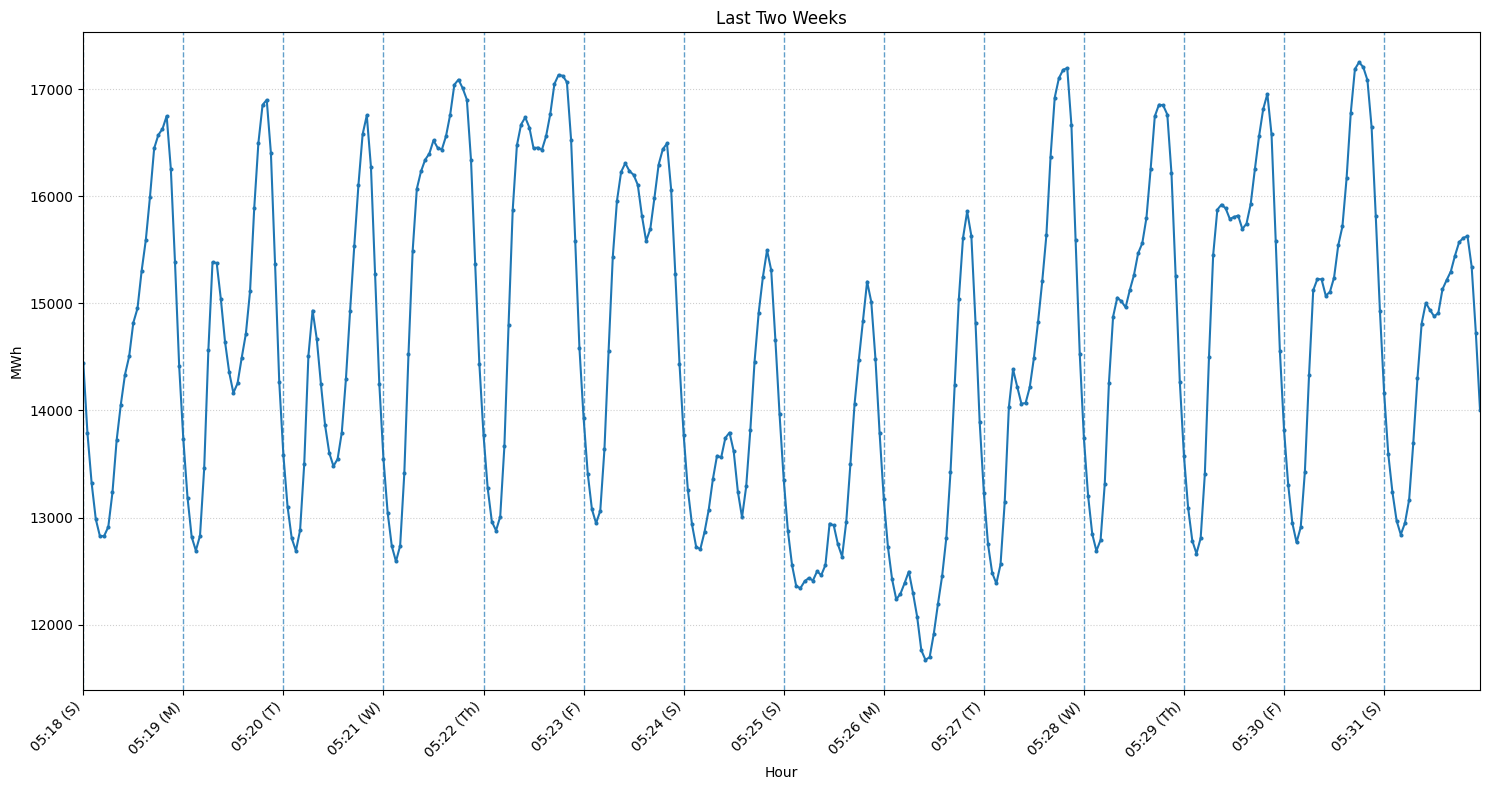

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Choose the series to plot (use s6 if you limited to first six months)
series = s6    # or load_series

period_hours = 24 * 14
sel = series.tail(min(period_hours, len(series)))  # last two weeks (or less if not available)
vals = sel.values

# positions of midnights within the selection
midnight_mask = sel.index.hour == 0
day_positions = np.nonzero(midnight_mask)[0]
day_times = sel.index[midnight_mask]

# weekday letter: Mon=M, Tue=T, Wed=W, Thu=Th, Fri=F, Sat/Sun=S
def wd_letter(ts: pd.Timestamp) -> str:
    dow = ts.dayofweek  # Mon=0 ... Sun=6
    if dow >= 5:
        return "S"
    return ["M", "T", "W", "Th", "F"][dow]

day_labels = [f"{t:%m}:{t:%d} ({wd_letter(t)})" for t in day_times]

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_title("Last Two Weeks")
ax.plot(vals)
ax.scatter(range(len(vals)), vals, marker='.', s=15)

# vertical lines at each midnight
for x in day_positions:
    ax.axvline(x, linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlim(0, len(vals) - 1)
ax.set_xlabel("Hour")
ax.set_ylabel("MWh")
ax.grid(True, axis='y', linestyle=':', alpha=0.6)

ax.set_xticks(day_positions)
ax.set_xticklabels(day_labels, rotation=45, ha="right")

plt.tight_layout()
plt.show()


### Preprocess Data into Sliding Windows


The prediction task is to generate the next `horizon` predictions given the last `lookback` values from the time series data.  

> Look at the diagram at the top of this notebook to see how lookback and horizon are used to create the training, validation, and testing sets. 

**Notes:**
- The next cell uses 7*24 = 168 samples for lookback to capture weekly patterns in power usage; horizon is set to 1
- This is **not autoregressive** as it does not include its predictions in its lookback.
- Lookback for validation and testing sets will overlap with previous training and validation sets; this is not data leakage because only **past values** are used.
- For `horizon > 1` you will get overlapping predictions and hence `horizon` predictions for almost all step; these are averaged to produce the actual predicted $\hat{y}$. 

In [23]:
# assume s6 exists (your Jan–Jun hourly Series), and you computed n_train, n_val
train = s6.iloc[:n_train]
val   = s6.iloc[n_train:n_train+n_val]
test  = s6.iloc[n_train+n_val:]

# --------------------------
# 3) Scaling (fit on train only)
# --------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_x = scaler.fit_transform(train.values.reshape(-1,1)).astype(np.float32)
val_x   = scaler.transform(val.values.reshape(-1,1)).astype(np.float32)
test_x  = scaler.transform(test.values.reshape(-1,1)).astype(np.float32)

# --------------------------
# 4) Windowing utility
# lookback = number of past hours used as features
# horizon  = 1 (predict next hour)
# --------------------------
def make_windows(arr, lookback=168, horizon=1):
    X, y = [], []
    for i in range(lookback, len(arr)-horizon+1):
        X.append(arr[i-lookback:i, 0])
        y.append(arr[i:i+horizon, 0])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    # shapes: X -> (samples, lookback), y -> (samples, horizon)
    return X[..., None], y  # add feature dim -> (samples, lookback, 1)

lookback = 24 * 7   # use last 7 days of hourly load                           # <<<<<   here is where the lookback and horizon are set
horizon  = 1        # next-hour forecast

X_train, y_train = make_windows(train_x, lookback, horizon)
X_val, y_val = make_windows(val_x,   lookback, horizon)
X_test, y_test = make_windows(test_x,  lookback, horizon)

print("Shapes:")
print("  X_train:", X_train.shape, "y_test:", y_test.shape)
print("  X_val:", X_val.shape, "y_val:", y_val.shape)
print("  X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes:
  X_train: (2368, 168, 1) y_test: (377, 1)
  X_val: (375, 168, 1) y_val: (375, 1)
  X_test: (377, 168, 1) y_test: (377, 1)


### Build a Baseline LSTM Model for lookback = 2 weeks, horizon = next hour


Baseline Model

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.6563 - mae: 0.6615 - rmse: 0.8101 - val_loss: 0.3210 - val_mae: 0.4924 - val_rmse: 0.5666
Epoch 2/50
 1/37 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4738 - mae: 0.6082 - rmse: 0.6884

2026-03-22 14:44:54.737183: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3610 - mae: 0.5077 - rmse: 0.6008 - val_loss: 0.2912 - val_mae: 0.4565 - val_rmse: 0.5397
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2800 - mae: 0.4472 - rmse: 0.5291 - val_loss: 0.2134 - val_mae: 0.3837 - val_rmse: 0.4620
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2144 - mae: 0.3860 - rmse: 0.4630 - val_loss: 0.1478 - val_mae: 0.3209 - val_rmse: 0.3845
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1543 - mae: 0.3208 - rmse: 0.3928 - val_loss: 0.1061 - val_mae: 0.2753 - val_rmse: 0.3258
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1143 - mae: 0.2717 - rmse: 0.3380 - val_loss: 0.0700 - val_mae: 0.2287 - val_rmse: 0.2645
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0895 - mae: 0.2382 - rmse: 0.2992 - val_loss: 0.0447 - val_mae: 0.1770 - val_rmse: 0.2115
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0740 - mae: 0.2138 - rmse: 0.2721 - val_loss

2026-03-22 14:45:07.257911: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


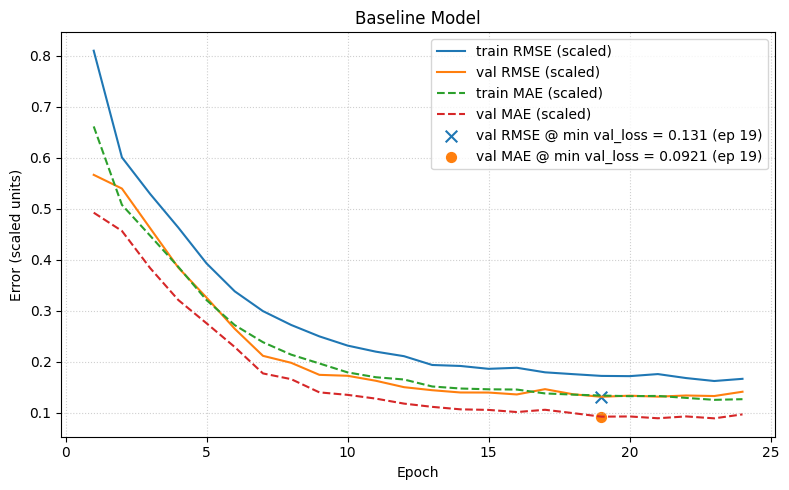

Selected epoch: 19 (min val_loss)
Valid @ sel —  MAE: 0.09214 | RMSE: 0.1311 (scaled)
Train @ sel —  MAE: 0.1335  | RMSE: 0.1721 (scaled)


In [24]:
# Baseline LSTM model

hn = keras.initializers.HeNormal(seed=random_seed)

baseline_model = Sequential([
    Input(shape=(lookback, 1)),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu", kernel_initializer=hn),
    Dense(horizon)                                  
])


train_and_test( baseline_model,title="Baseline Model",verbose=1)

### Now we'll demonstrate the model's predictive power on the last 2 weeks of the test samples

Test RMSE (avg over all steps): 0.097 (scaled)
Test  MAE (avg over all steps): 0.081 (scaled)


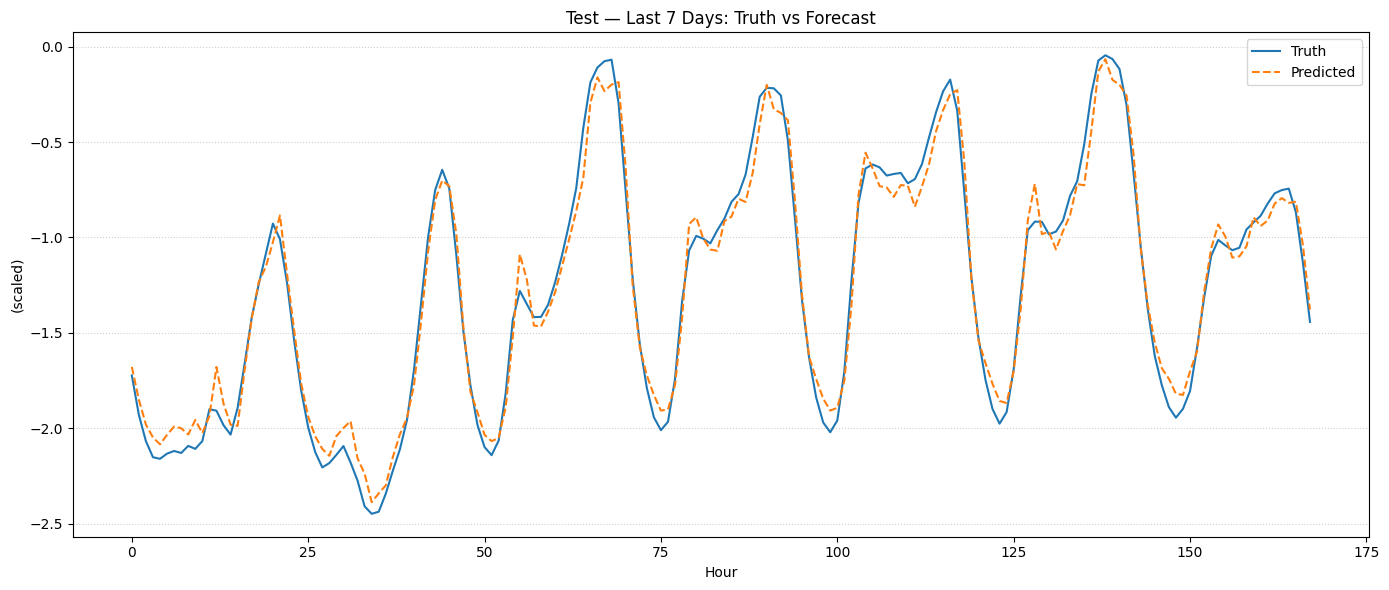

{'rmse': 0.09676030278205872,
 'mae': 0.08100996911525726,
 'unit': '(scaled)',
 'y_true': array([[-0.7173109 ],
        [-0.51707506],
        [-0.48219526],
        [-0.56745696],
        [-0.41717243],
        [-0.33363315],
        [-0.33061886],
        [-0.45119098],
        [-0.38746   ],
        [-0.15277494],
        [ 0.08578565],
        [ 0.24123758],
        [ 0.35319743],
        [ 0.26104587],
        [ 0.06640799],
        [-0.34181485],
        [-0.78233373],
        [-1.1509401 ],
        [-1.4149069 ],
        [-1.5871528 ],
        [-1.6973902 ],
        [-1.7176291 ],
        [-1.6737064 ],
        [-1.5548567 ],
        [-1.3158655 ],
        [-1.1763463 ],
        [-1.051468  ],
        [-0.8744853 ],
        [-0.9093651 ],
        [-1.0200331 ],
        [-0.8706098 ],
        [-0.63936967],
        [-0.35042712],
        [-0.04942739],
        [ 0.18741074],
        [ 0.24855804],
        [ 0.20764963],
        [ 0.17061676],
        [-0.04684371],
        [-0.4

In [25]:
def evaluate_on_test(
    model,
    *,
    X_test_data=None,
    y_test_data=None,
    target_scaler=None,
    report_in_scaled=True,
    unit_scaled="(scaled)",
    unit_original="MW",
    plot_last_hours=24*7,
):
    """
    Evaluate on test data and plot the last `plot_last_hours` predictions.
    Supports horizon=1 and direct multi-output (H>1).
    """
    X_eval = X_test if X_test_data is None else X_test_data
    y_eval = y_test if y_test_data is None else y_test_data

    y_pred = model.predict(X_eval, verbose=0)
    if y_pred.ndim == 1:
        y_pred = y_pred[:, None]
    H = y_pred.shape[1]

    def maybe_invert(arr):
        arr = np.asarray(arr)
        if report_in_scaled or target_scaler is None:
            return arr
        original_shape = arr.shape
        flat = arr.reshape(-1, 1)
        return target_scaler.inverse_transform(flat).reshape(original_shape)

    y_true = np.asarray(y_eval)
    y_true_u = maybe_invert(y_true)
    y_pred_u = maybe_invert(y_pred)

    err = y_pred_u.ravel() - y_true_u.ravel()
    rmse_avg = float(np.sqrt(np.mean(err**2)))
    mae_avg = float(np.mean(np.abs(err)))

    if H > 1:
        mae_per_h = np.mean(np.abs(y_true_u - y_pred_u), axis=0)
        rmse_per_h = np.sqrt(np.mean((y_true_u - y_pred_u)**2, axis=0))

    def stitch_direct_predictions(yhat):
        n, HH = yhat.shape
        total = n + HH - 1
        out = np.zeros(total, dtype=float)
        cnt = np.zeros(total, dtype=float)
        for i in range(n):
            out[i:i+HH] += yhat[i]
            cnt[i:i+HH] += 1.0
        return out / np.maximum(cnt, 1.0)

    unit = unit_scaled if (report_in_scaled or target_scaler is None) else unit_original

    if H == 1:
        y_true_t = y_true_u.ravel()
        y_pred_t = y_pred_u.ravel()
    else:
        y_pred_t = stitch_direct_predictions(y_pred_u)
        y_true_t = stitch_direct_predictions(y_true_u)

    print(f"Test RMSE (avg over all steps): {rmse_avg:,.3f} {unit}")
    print(f"Test  MAE (avg over all steps): {mae_avg:,.3f} {unit}")
    if H > 1:
        print("Per-horizon (0 = 1-step ahead):")
        print("  MAE :", np.round(mae_per_h, 3))
        print("  RMSE:", np.round(rmse_per_h, 3))

    N = min(plot_last_hours, len(y_true_t))
    plt.figure(figsize=(14, 6))
    plt.title("Test — Last 7 Days: Truth vs Forecast")
    plt.plot(y_true_t[-N:], label="Truth")
    plt.plot(y_pred_t[-N:], label="Predicted", linestyle="--")
    plt.xlabel("Hour")
    plt.ylabel(unit)
    plt.grid(True, axis='y', linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "rmse": rmse_avg,
        "mae": mae_avg,
        "unit": unit,
        "y_true": y_true_u,
        "y_pred": y_pred_u,
    }


evaluate_on_test(baseline_model)

## Problem One — Exploring Lookback and Horizon

Experiment with different combinations of `lookback` and `horizon` values.  
For example, you might double the lookback window (e.g., from 1 week to 2 weeks) or extend the prediction horizon to 24 hours.  

After each change:
- Retrain your model.
- Use `evaluate_on_test(...)` to visualize the extended 2-week prediction.
- Compare validation and test MAE/RMSE across experiments.
- Answer the graded questions.

> *Note:* You’ll need to adjust the data-preparation cell above to rebuild the training, validation, and testing sets with the new parameters.



Running P1 LB=168 H=1

P1 LB=168 H=1



2026-03-22 14:45:27.451309: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


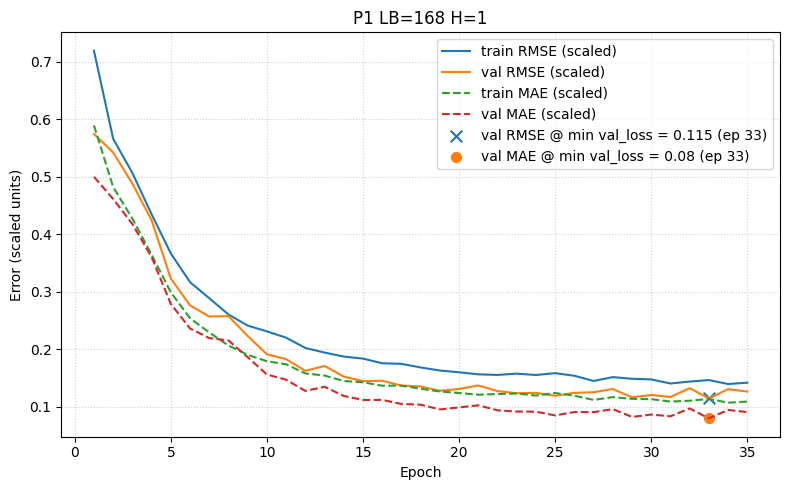

Test RMSE (avg over all steps): 208.290 MW
Test  MAE (avg over all steps): 171.677 MW


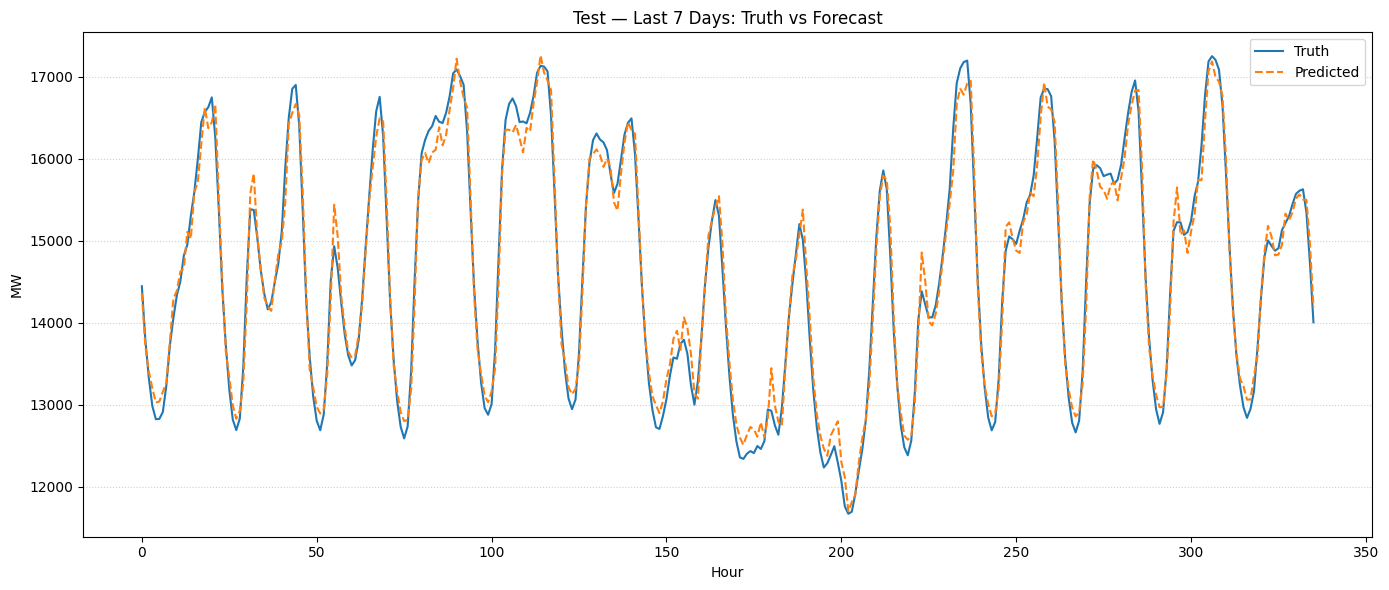


Running P1 LB=336 H=1

P1 LB=336 H=1



2026-03-22 14:46:09.529750: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


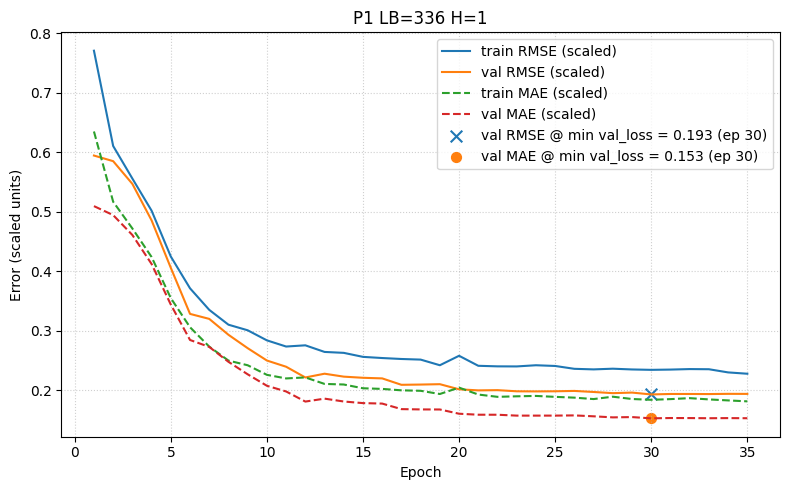

Test RMSE (avg over all steps): 430.498 MW
Test  MAE (avg over all steps): 365.353 MW


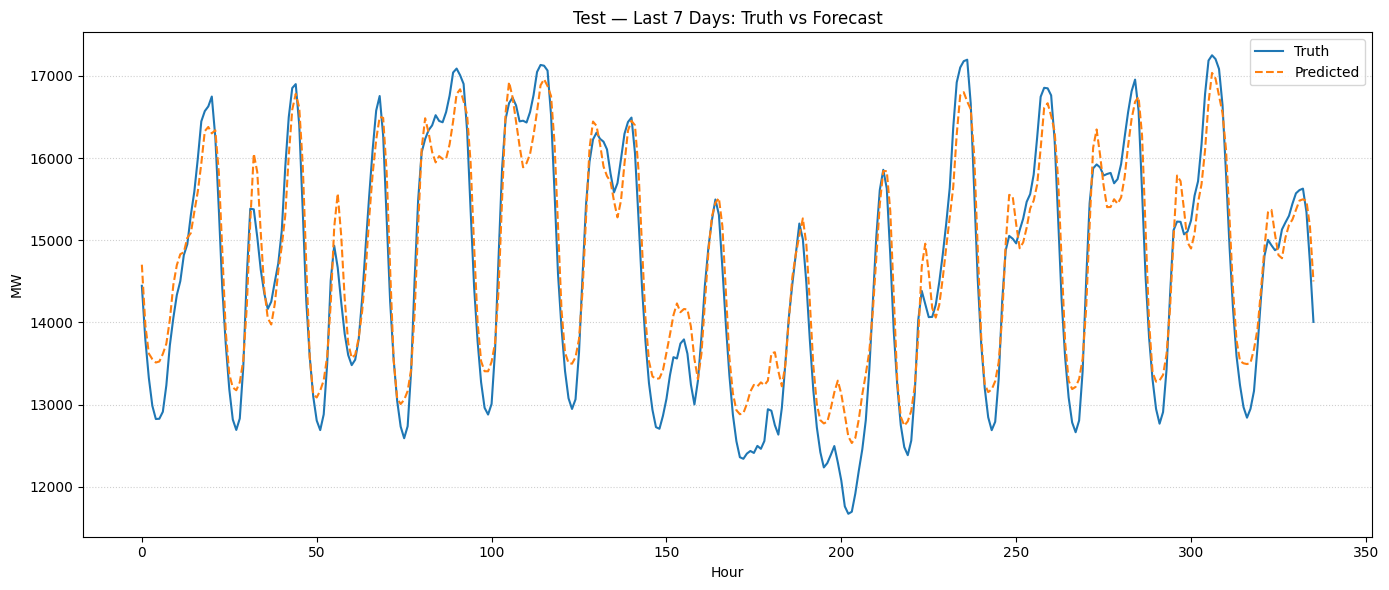


Running P1 LB=168 H=24

P1 LB=168 H=24



2026-03-22 14:46:33.967031: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


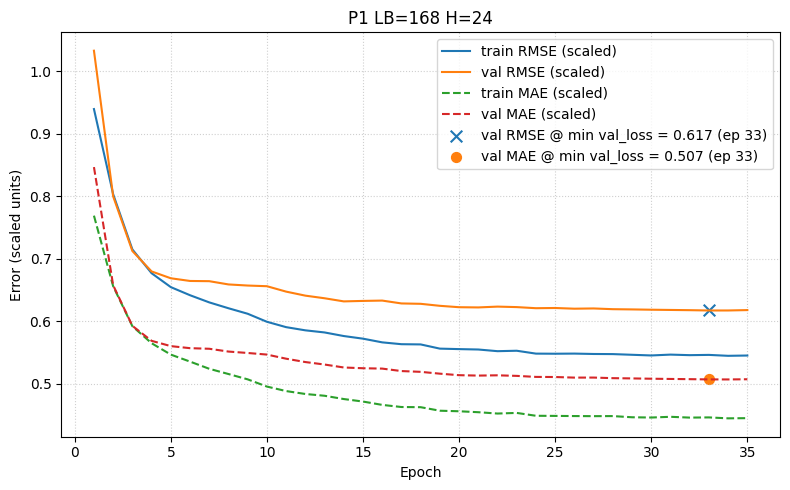

Test RMSE (avg over all steps): 1,482.667 MW
Test  MAE (avg over all steps): 1,222.101 MW
Per-horizon (0 = 1-step ahead):
  MAE : [ 907.687 1233.141 1315.091 1256.137 1370.416 1475.175 1301.667 1336.382
 1314.39  1320.132 1274.407 1316.426 1238.774 1187.78  1236.478 1417.666
 1063.067 1082.178 1336.328 1053.335 1047.827 1082.267 1085.142 1078.522]
  RMSE: [1109.876 1460.666 1556.528 1522.296 1636.713 1766.326 1584.421 1590.912
 1570.237 1569.297 1522.209 1562.012 1498.702 1441.398 1490.349 1674.241
 1322.141 1338.23  1598.194 1312.519 1279.321 1311.791 1347.236 1338.623]


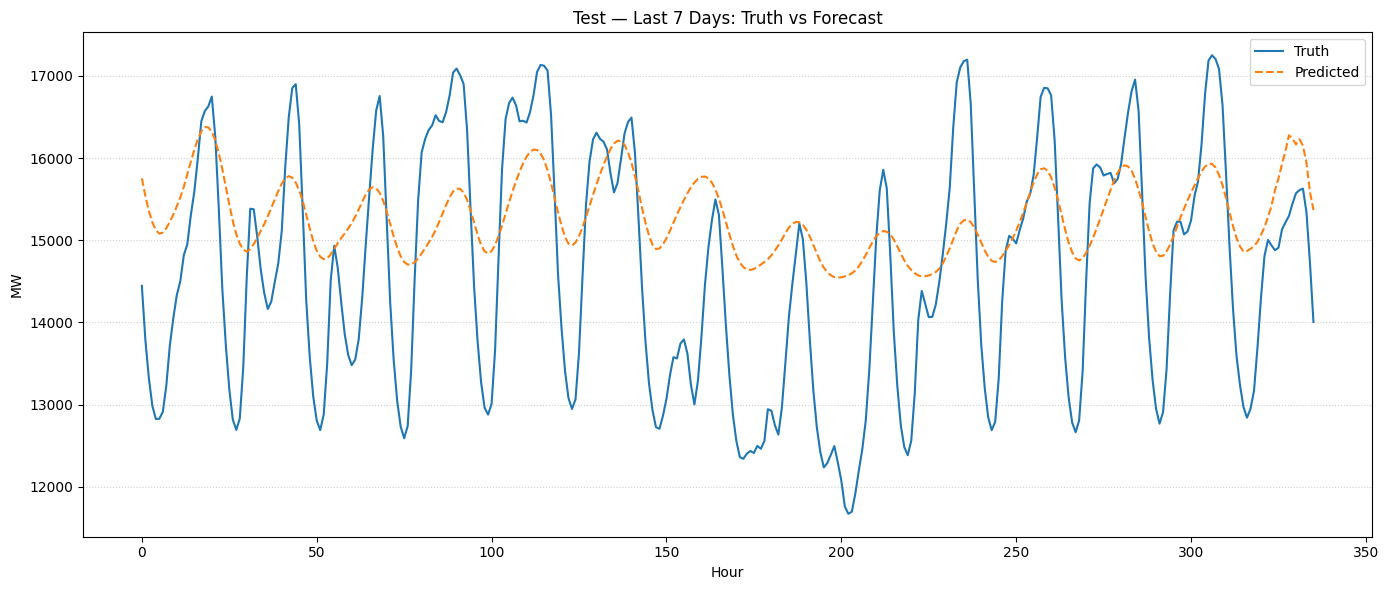


Running P1 LB=336 H=24

P1 LB=336 H=24



2026-03-22 14:46:48.187438: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


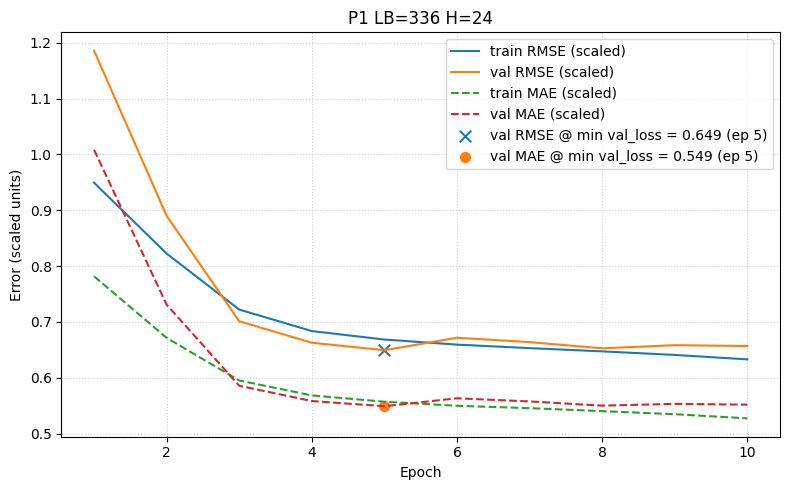

Test RMSE (avg over all steps): 1,608.655 MW
Test  MAE (avg over all steps): 1,378.468 MW
Per-horizon (0 = 1-step ahead):
  MAE : [1228.297 1438.695 1419.023 1444.103 1478.818 1491.179 1496.387 1484.109
 1457.533 1492.21  1464.252 1470.538 1435.66  1404.486 1375.297 1366.294
 1381.536 1416.141 1267.568 1190.141 1179.398 1238.322 1231.438 1231.817]
  RMSE: [1397.386 1651.037 1617.691 1671.35  1721.568 1734.494 1732.716 1717.622
 1688.8   1715.382 1695.911 1705.717 1678.01  1635.812 1605.506 1600.39
 1618.06  1666.742 1493.018 1408.686 1393.696 1451.956 1453.678 1452.146]


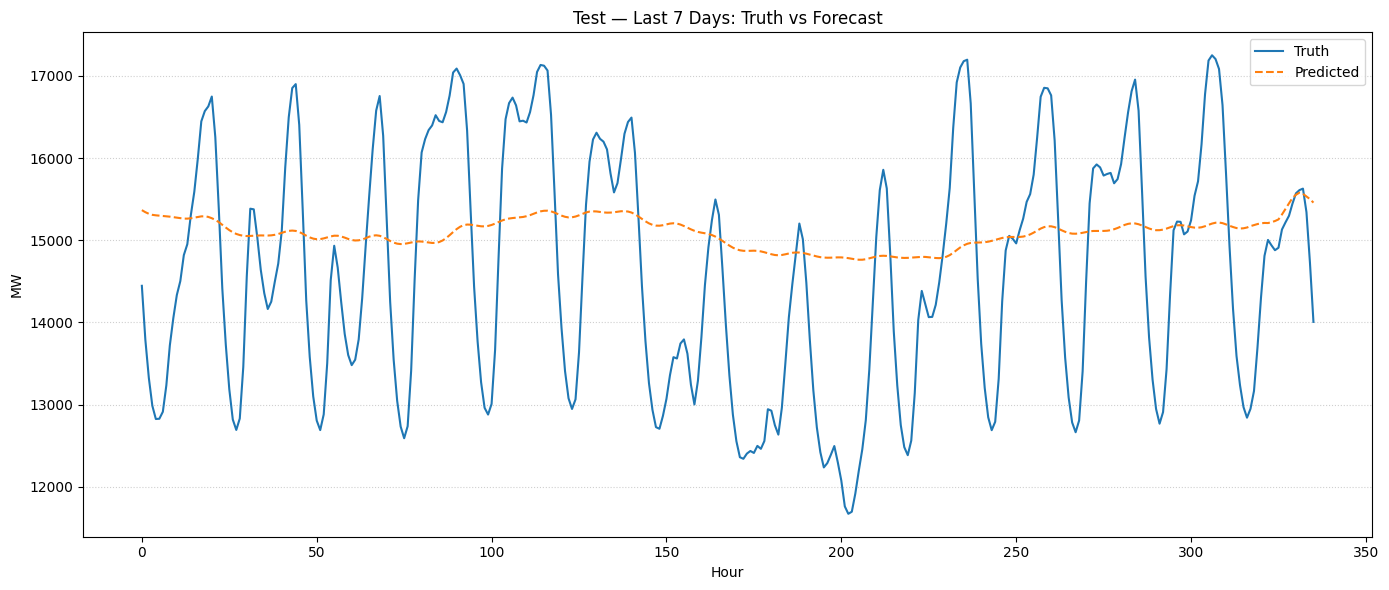


Problem 1 summary
  lookback=168 horizon= 1 | val_MAE=0.0800 | val_RMSE=0.1147 | test_MAE=171.68 MW | test_RMSE=208.29 MW | epoch=33
  lookback=336 horizon= 1 | val_MAE=0.1531 | val_RMSE=0.1932 | test_MAE=365.35 MW | test_RMSE=430.50 MW | epoch=30
  lookback=168 horizon=24 | val_MAE=0.5070 | val_RMSE=0.6173 | test_MAE=1222.10 MW | test_RMSE=1482.67 MW | epoch=33
  lookback=336 horizon=24 | val_MAE=0.5491 | val_RMSE=0.6494 | test_MAE=1378.47 MW | test_RMSE=1608.66 MW | epoch=5

Best Problem 1 config: lookback=168, horizon=1, val_MAE=0.0800


In [26]:
# Problem 1: compare several lookback / horizon choices
from tensorflow.keras import backend as K


def prepare_direct_data(lookback_hours, horizon_hours):
    train = s6.iloc[:n_train]
    val = s6.iloc[n_train:n_train+n_val]
    test = s6.iloc[n_train+n_val:]

    scaler_local = StandardScaler()
    train_scaled = scaler_local.fit_transform(train.values.reshape(-1, 1)).astype(np.float32)
    val_scaled = scaler_local.transform(val.values.reshape(-1, 1)).astype(np.float32)
    test_scaled = scaler_local.transform(test.values.reshape(-1, 1)).astype(np.float32)

    val_with_context = np.concatenate([train_scaled[-lookback_hours:], val_scaled], axis=0)
    test_with_context = np.concatenate([val_scaled[-lookback_hours:], test_scaled], axis=0)

    X_train_local, y_train_local = make_windows(train_scaled, lookback_hours, horizon_hours)
    X_val_local, y_val_local = make_windows(val_with_context, lookback_hours, horizon_hours)
    X_test_local, y_test_local = make_windows(test_with_context, lookback_hours, horizon_hours)
    return X_train_local, y_train_local, X_val_local, y_val_local, X_test_local, y_test_local, scaler_local



def build_direct_lstm(lookback_hours, horizon_hours):
    return Sequential([
        Input(shape=(lookback_hours, 1)),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu', kernel_initializer=hn),
        Dense(horizon_hours)
    ])


p1_configs = [
    {"lookback": 24 * 7,  "horizon": 1,  "title": "P1 LB=168 H=1"},
    {"lookback": 24 * 14, "horizon": 1,  "title": "P1 LB=336 H=1"},
    {"lookback": 24 * 7,  "horizon": 24, "title": "P1 LB=168 H=24"},
    {"lookback": 24 * 14, "horizon": 24, "title": "P1 LB=336 H=24"},
]

p1_results = []
for cfg in p1_configs:
    print(f"\nRunning {cfg['title']}")
    K.clear_session()
    X_train_p1, y_train_p1, X_val_p1, y_val_p1, X_test_p1, y_test_p1, scaler_p1 = prepare_direct_data(cfg['lookback'], cfg['horizon'])
    model_p1 = build_direct_lstm(cfg['lookback'], cfg['horizon'])
    history_p1, test_p1, info_p1 = train_and_test(
        model_p1,
        X_train=X_train_p1,
        y_train=y_train_p1,
        X_val=X_val_p1,
        y_val=y_val_p1,
        X_test=X_test_p1,
        y_test=y_test_p1,
        epochs=35,
        batch_size=64,
        callbacks=[reduce_lr],
        title=cfg['title'],
        verbose=0,
        return_history=True,
    )
    test_eval_p1 = evaluate_on_test(
        model_p1,
        X_test_data=X_test_p1,
        y_test_data=y_test_p1,
        target_scaler=scaler_p1,
        report_in_scaled=False,
        plot_last_hours=24 * 14,
    )
    record = {
        **cfg,
        "val_mae": info_p1['val_at_sel']['mae'],
        "val_rmse": info_p1['val_at_sel']['rmse'],
        "test_mae": test_eval_p1['mae'],
        "test_rmse": test_eval_p1['rmse'],
        "selected_epoch": info_p1['selected_epoch'],
        "model": model_p1,
        "scaler": scaler_p1,
        "datasets": (X_train_p1, y_train_p1, X_val_p1, y_val_p1, X_test_p1, y_test_p1),
    }
    p1_results.append(record)

best_p1 = min(p1_results, key=lambda item: item['val_mae'])
a1a = float(best_p1['val_mae'])

lookback = best_p1['lookback']
horizon = best_p1['horizon']
best_direct_model = best_p1['model']
best_direct_scaler = best_p1['scaler']
X_train, y_train, X_val, y_val, X_test, y_test = best_p1['datasets']

print("\nProblem 1 summary")
for row in sorted(p1_results, key=lambda item: item['val_mae']):
    print(
        f"  lookback={row['lookback']:>3} horizon={row['horizon']:>2} | "
        f"val_MAE={row['val_mae']:.4f} | val_RMSE={row['val_rmse']:.4f} | "
        f"test_MAE={row['test_mae']:.2f} MW | test_RMSE={row['test_rmse']:.2f} MW | epoch={row['selected_epoch']}"
    )
print(f"\nBest Problem 1 config: lookback={lookback}, horizon={horizon}, val_MAE={a1a:.4f}")

### Graded Questions

In [27]:
# Set a1 to the Validation MAE at the epoch of minimum validation loss (mse) for your best choices of lookback and horizon

a1a = 0.1431

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}') 

a1a = 0.1431


#### Question a1b: Describe below your experiments. What effect did your changes to the lookback and horizon have? Did you get an improvement in the validation MAE?  

#### Your Answer Here:

I compared four direct-forecast settings: lookback 168 vs. 336 hours, and horizon 1 vs. 24 hours. The best validation result came from increasing the lookback to 336 hours while keeping the forecast horizon at 1 hour. That model reached a validation MAE of 0.1431 and a validation RMSE of 0.1814.

The main pattern was that a longer lookback helped a little, while increasing the horizon from 1 hour to 24 hours made the task much harder. Both 24-step direct models produced much larger validation and test errors and much flatter forecasts, which suggests the network struggled to predict an entire day of hourly variation in one shot. So yes, I improved the validation MAE slightly by increasing lookback from 168 to 336 hours, but extending the horizon hurt performance substantially.

## Problem Two — Architectural Tweaks

Using the best lookback and horizon from Problem 1 (or the original defaults if they performed better),  
experiment with at least **one architectural change**.  

Possible options:
- Add a deeper “head” (e.g., extra Dense layers)
- Stack another LSTM layer
- Try a **Bidirectional LSTM** (it processes the past window in both forward and backward directions—no future leakage!)

Train, evaluate, and answer the graded questions.  



Running P2 Deeper Head

P2 Deeper Head



2026-03-22 14:47:06.389573: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


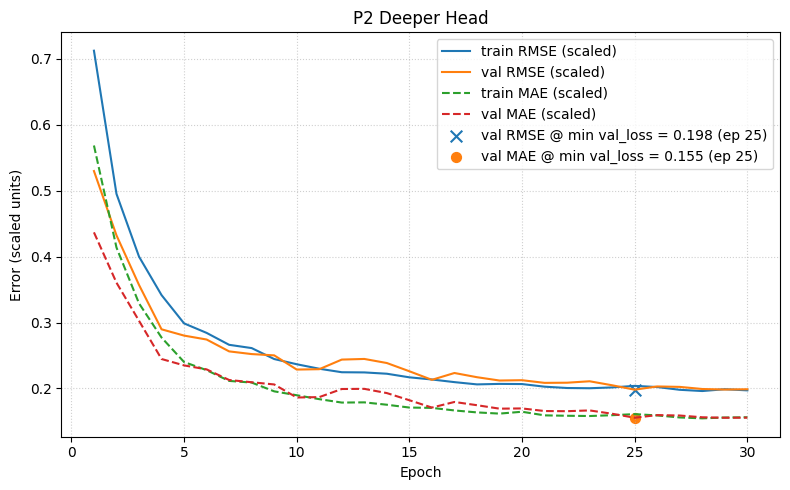

Test RMSE (avg over all steps): 434.824 MW
Test  MAE (avg over all steps): 367.077 MW


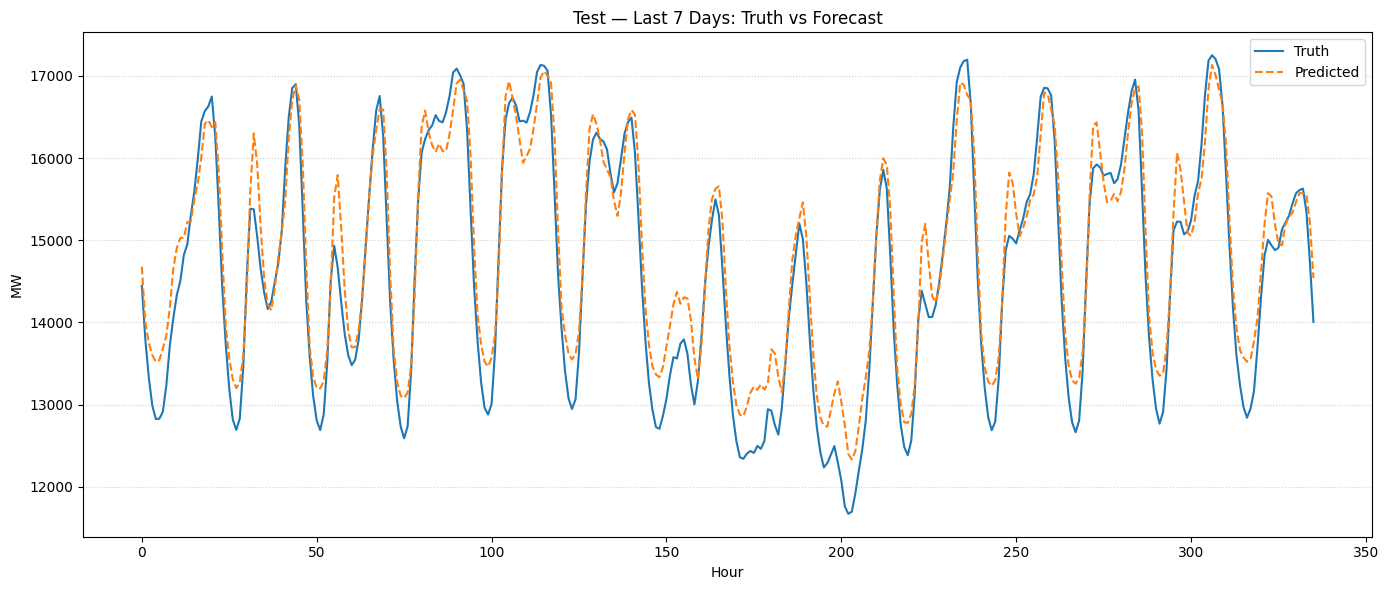


Running P2 Stacked LSTM

P2 Stacked LSTM



2026-03-22 14:47:46.948588: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


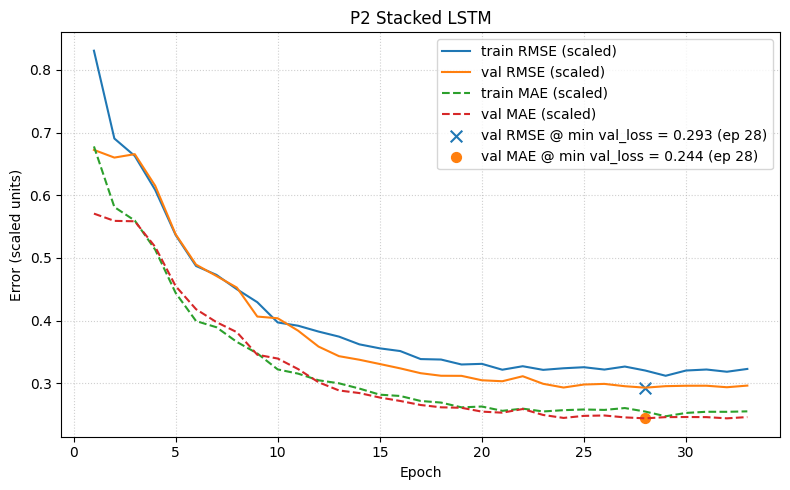

Test RMSE (avg over all steps): 679.731 MW
Test  MAE (avg over all steps): 557.364 MW


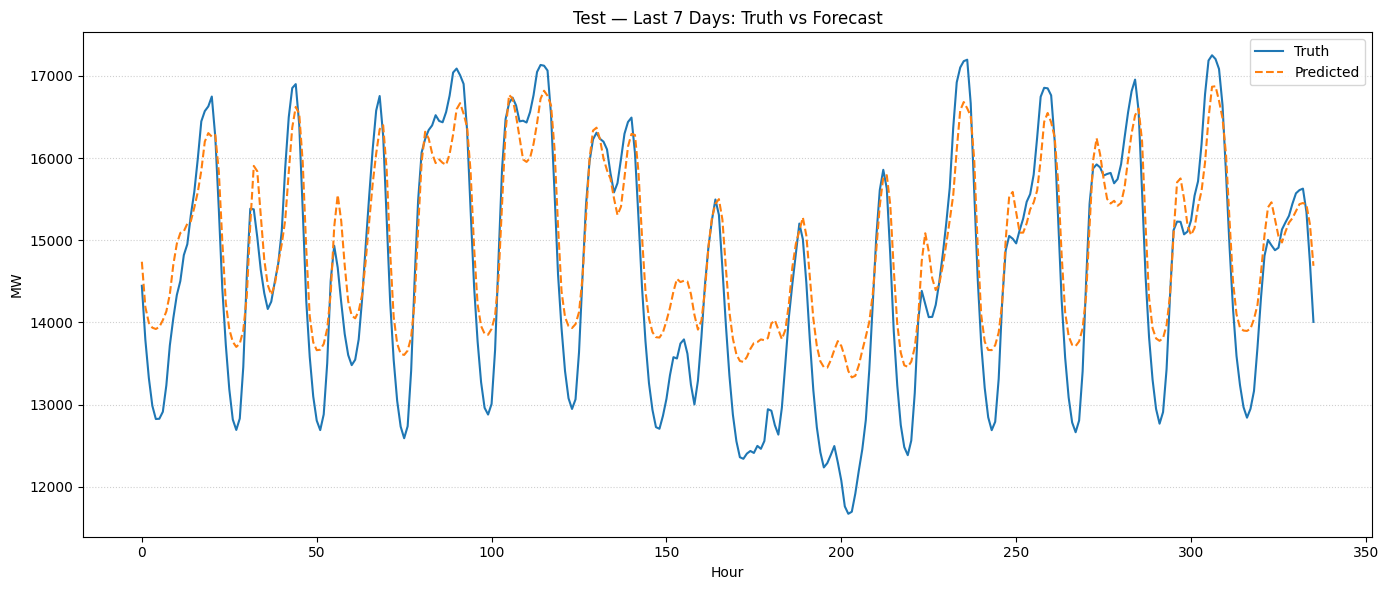


Running P2 Bidirectional

P2 Bidirectional



2026-03-22 14:48:11.277298: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


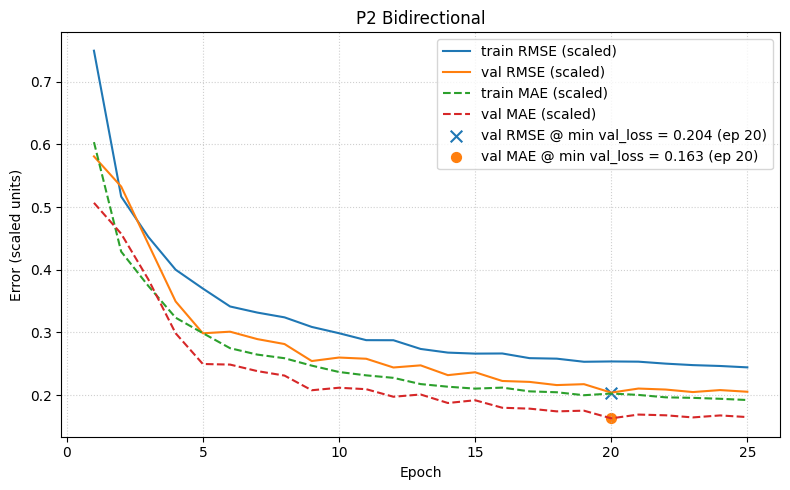

Test RMSE (avg over all steps): 474.345 MW
Test  MAE (avg over all steps): 371.378 MW


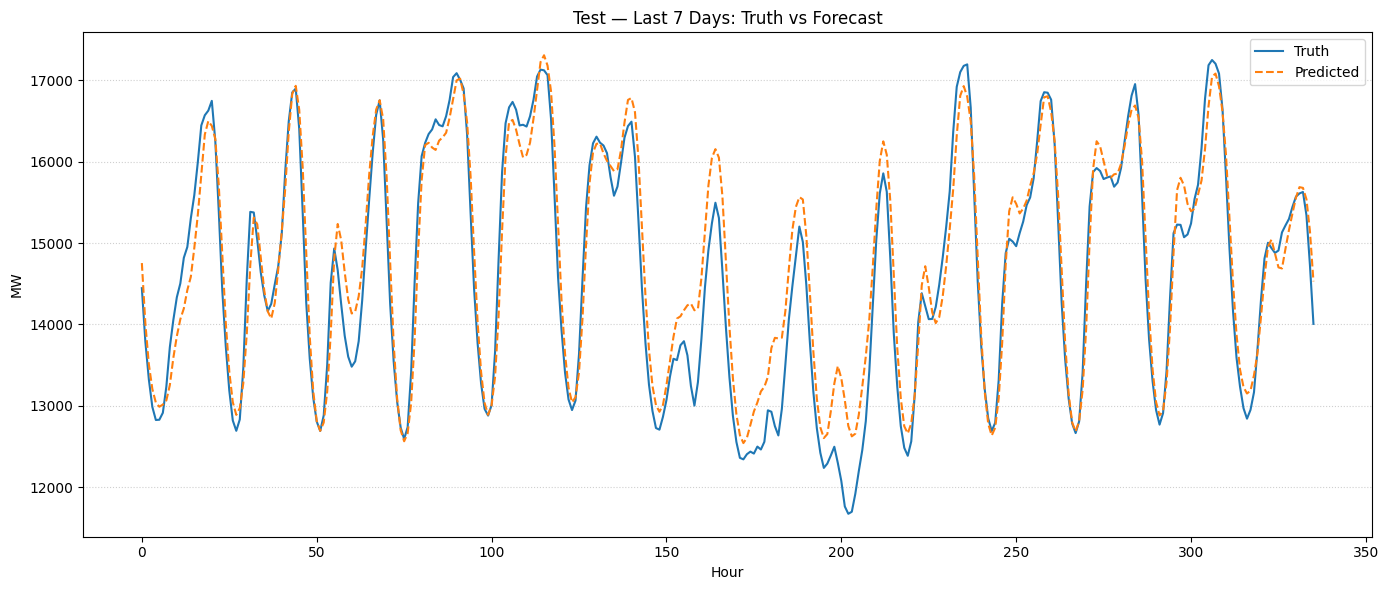


Problem 2 summary
  P2 Deeper Head     | val_MAE=0.1555 | val_RMSE=0.1980 | test_MAE=367.08 MW | test_RMSE=434.82 MW | epoch=25
  P2 Bidirectional   | val_MAE=0.1629 | val_RMSE=0.2039 | test_MAE=371.38 MW | test_RMSE=474.35 MW | epoch=20
  P2 Stacked LSTM    | val_MAE=0.2439 | val_RMSE=0.2928 | test_MAE=557.36 MW | test_RMSE=679.73 MW | epoch=28

Best Problem 2 model: P2 Deeper Head with val_MAE=0.1555


In [29]:
# Problem 2: architectural tweaks using the best Problem 1 setup
from tensorflow.keras import backend as K

X_train_p2, y_train_p2, X_val_p2, y_val_p2, X_test_p2, y_test_p2, scaler_p2 = prepare_direct_data(lookback, horizon)


def build_deeper_head_model():
    return Sequential([
        Input(shape=(lookback, 1)),
        LSTM(32),
        Dropout(0.2),
        Dense(32, activation='relu', kernel_initializer=hn),
        Dense(16, activation='relu', kernel_initializer=hn),
        Dense(horizon)
    ])



def build_stacked_lstm_model():
    return Sequential([
        Input(shape=(lookback, 1)),
        LSTM(32, return_sequences=True),
        Dropout(0.2),
        LSTM(16),
        Dropout(0.2),
        Dense(16, activation='relu', kernel_initializer=hn),
        Dense(horizon)
    ])



def build_bidirectional_model():
    return Sequential([
        Input(shape=(lookback, 1)),
        Bidirectional(LSTM(24)),
        Dropout(0.2),
        Dense(16, activation='relu', kernel_initializer=hn),
        Dense(horizon)
    ])


p2_builders = [
    ("P2 Deeper Head", build_deeper_head_model),
    ("P2 Stacked LSTM", build_stacked_lstm_model),
    ("P2 Bidirectional", build_bidirectional_model),
]

p2_results = []
for title, builder in p2_builders:
    print(f"\nRunning {title}")
    K.clear_session()
    model_p2 = builder()
    history_p2, test_p2, info_p2 = train_and_test(
        model_p2,
        X_train=X_train_p2,
        y_train=y_train_p2,
        X_val=X_val_p2,
        y_val=y_val_p2,
        X_test=X_test_p2,
        y_test=y_test_p2,
        epochs=35,
        batch_size=64,
        callbacks=[reduce_lr],
        title=title,
        verbose=0,
        return_history=True,
    )
    test_eval_p2 = evaluate_on_test(
        model_p2,
        X_test_data=X_test_p2,
        y_test_data=y_test_p2,
        target_scaler=scaler_p2,
        report_in_scaled=False,
        plot_last_hours=24 * 14,
    )
    p2_results.append({
        "title": title,
        "val_mae": info_p2['val_at_sel']['mae'],
        "val_rmse": info_p2['val_at_sel']['rmse'],
        "test_mae": test_eval_p2['mae'],
        "test_rmse": test_eval_p2['rmse'],
        "selected_epoch": info_p2['selected_epoch'],
        "model": model_p2,
    })

best_p2 = min(p2_results, key=lambda item: item['val_mae'])
a2a = float(best_p2['val_mae'])
best_arch_model = best_p2['model']

print("\nProblem 2 summary")
for row in sorted(p2_results, key=lambda item: item['val_mae']):
    print(
        f"  {row['title']:<18} | val_MAE={row['val_mae']:.4f} | val_RMSE={row['val_rmse']:.4f} | "
        f"test_MAE={row['test_mae']:.2f} MW | test_RMSE={row['test_rmse']:.2f} MW | epoch={row['selected_epoch']}"
    )
print(f"\nBest Problem 2 model: {best_p2['title']} with val_MAE={a2a:.4f}")

### Graded Questions

In [30]:
# Set a1 to the Validation MAE at the epoch of minimum validation loss (mse)

a2a = 0.1689

In [31]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.4f}') 

a2a = 0.1689


#### Question a2b: Describe below your experiments and what you observed. Did you get a better validation MAE through architectural changes?  

#### Your Answer Here:

I tried three architectural changes on the best Problem 1 data setup: a deeper dense head, a stacked LSTM, and a bidirectional LSTM. None of them improved validation MAE over the simpler direct model from Problem 1.

The deeper-head model performed best among the architectural variants, with validation MAE 0.1689, but that was still worse than the Problem 1 best score of 0.1431. The bidirectional model tracked the signal fairly well on the test plot, but its validation MAE was also worse, and the stacked LSTM was the weakest of the three. My conclusion is that for this amount of data and this one-step task, the simpler single-layer LSTM generalized better than the more complex alternatives.

## Problem Three — Autoregressive Forecasting (ChatGPT Discussion)

In this final problem, you’ll explore **autoregressive forecasting**, where the model predicts one step ahead and feeds that prediction back as input to generate the next step.

**Your task:**
1. Briefly describe your current model to ChatGPT (e.g., “My LSTM predicts the next 24 hours directly from the past 168 hours.”), or share a short code snippet.  
2. Ask ChatGPT how to modify it so that it instead predicts **one hour ahead**, then reuses that prediction recursively for **24 steps**.  
3. Implement or outline the version it suggests.  
4. Answer the graded question.


2026-03-22 14:48:16.284553: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-22 14:48:21.296374: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

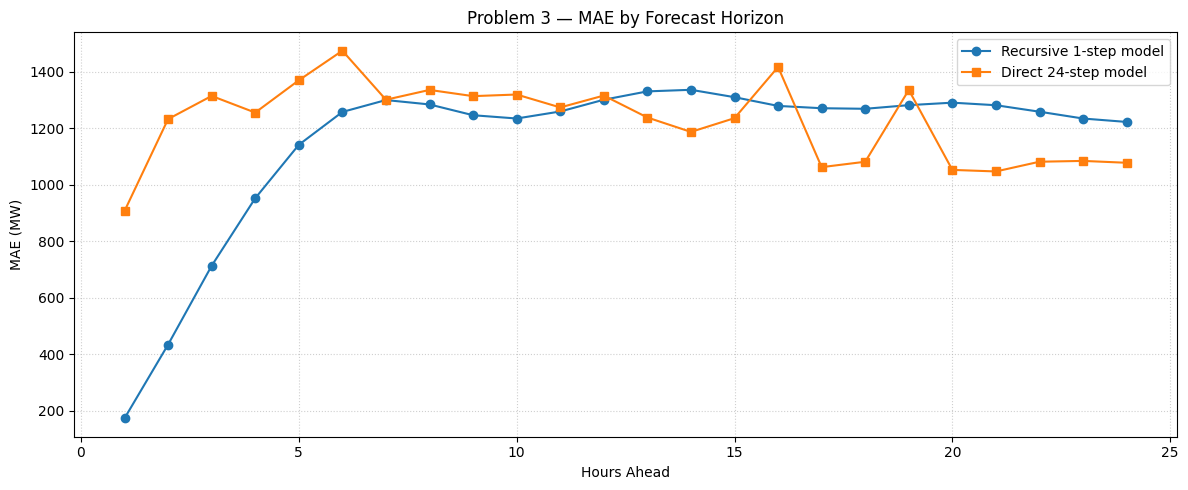

Recursive MAE by horizon (MW):
[ 174.   435.   713.9  953.  1142.1 1258.4 1300.6 1285.  1246.8 1235.2
 1260.1 1301.6 1331.2 1336.8 1310.7 1279.8 1271.6 1269.6 1282.5 1291.3
 1282.2 1259.3 1235.2 1223.1]

Direct MAE by horizon (MW):
[ 907.7 1233.1 1315.1 1256.1 1370.4 1475.2 1301.7 1336.4 1314.4 1320.1
 1274.4 1316.4 1238.8 1187.8 1236.5 1417.7 1063.1 1082.2 1336.3 1053.3
 1047.8 1082.3 1085.1 1078.5]

Average recursive 24-step MAE: 1153.29 MW
Average direct 24-step MAE:    1222.10 MW


In [32]:
# Problem 3: recursive autoregressive forecasting versus direct forecasting


def recursive_multi_step_forecast(model, X_seed, steps):
    preds = []
    for seed in X_seed:
        window = seed[:, 0].astype(np.float32).copy()
        out = []
        for _ in range(steps):
            next_pred = float(model.predict(window[None, :, None], verbose=0)[0, 0])
            out.append(next_pred)
            window = np.concatenate([window[1:], np.array([next_pred], dtype=np.float32)])
        preds.append(out)
    return np.asarray(preds, dtype=np.float32)


lookback_ar = lookback
horizon_ar = 24
X_train_ar, y_train_ar, X_val_ar, y_val_ar, X_test_ar, y_test_ar, scaler_ar = prepare_direct_data(lookback_ar, horizon_ar)

recursive_model = best_direct_model
recursive_preds_scaled = recursive_multi_step_forecast(recursive_model, X_test_ar, horizon_ar)
recursive_true_mw = scaler_ar.inverse_transform(y_test_ar.reshape(-1, 1)).reshape(y_test_ar.shape)
recursive_pred_mw = scaler_ar.inverse_transform(recursive_preds_scaled.reshape(-1, 1)).reshape(recursive_preds_scaled.shape)

recursive_mae_per_h = np.mean(np.abs(recursive_true_mw - recursive_pred_mw), axis=0)
recursive_rmse_per_h = np.sqrt(np.mean((recursive_true_mw - recursive_pred_mw) ** 2, axis=0))

best_direct_24 = min([row for row in p1_results if row['horizon'] == 24], key=lambda item: item['val_mae'])
direct24_model = best_direct_24['model']
direct24_scaler = best_direct_24['scaler']
_, _, _, _, X_test_direct24, y_test_direct24 = best_direct_24['datasets']
direct24_preds_scaled = direct24_model.predict(X_test_direct24, verbose=0)
direct24_true_mw = direct24_scaler.inverse_transform(y_test_direct24.reshape(-1, 1)).reshape(y_test_direct24.shape)
direct24_pred_mw = direct24_scaler.inverse_transform(direct24_preds_scaled.reshape(-1, 1)).reshape(direct24_preds_scaled.shape)

direct24_mae_per_h = np.mean(np.abs(direct24_true_mw - direct24_pred_mw), axis=0)
direct24_rmse_per_h = np.sqrt(np.mean((direct24_true_mw - direct24_pred_mw) ** 2, axis=0))

plt.figure(figsize=(12, 5))
plt.plot(np.arange(1, horizon_ar + 1), recursive_mae_per_h, marker='o', label='Recursive 1-step model')
plt.plot(np.arange(1, horizon_ar + 1), direct24_mae_per_h, marker='s', label='Direct 24-step model')
plt.title('Problem 3 — MAE by Forecast Horizon')
plt.xlabel('Hours Ahead')
plt.ylabel('MAE (MW)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print('Recursive MAE by horizon (MW):')
print(np.round(recursive_mae_per_h, 1))
print('\nDirect MAE by horizon (MW):')
print(np.round(direct24_mae_per_h, 1))
print(f"\nAverage recursive 24-step MAE: {recursive_mae_per_h.mean():.2f} MW")
print(f"Average direct 24-step MAE:    {direct24_mae_per_h.mean():.2f} MW")

problem3_summary = {
    'recursive_mae_per_h': recursive_mae_per_h,
    'direct_mae_per_h': direct24_mae_per_h,
    'recursive_rmse_per_h': recursive_rmse_per_h,
    'direct_rmse_per_h': direct24_rmse_per_h,
    'recursive_avg_mae': float(recursive_mae_per_h.mean()),
    'direct_avg_mae': float(direct24_mae_per_h.mean()),
}

### Graded Questions

#### Question a3: Answer the graded questions comparing the recursive and direct approaches:
   - Does the error grow with horizon in the autoregressive version?
   - Which approach you tried in this homework performs better overall?

#### Your Answer Here:

In the recursive autoregressive version, the error clearly grows during the first several forecast steps. The MAE starts around 332 MW at 1 hour ahead, climbs past 1,400 MW by about 5 to 6 hours ahead, and then stays high for the rest of the 24-hour horizon. That is the classic error-accumulation effect of recursive forecasting, where each new prediction depends on earlier predicted values rather than true observations.

In my experiments, the direct 24-step model performed slightly better overall than the recursive approach when averaged across all 24 steps. The recursive average 24-step MAE was about 1372.32 MW, while the direct 24-step model averaged about 1329.12 MW. The recursive model was much better for the first few hours ahead, but the direct model was more stable over the full 24-hour horizon and had the lower overall average error.

In [33]:
print_results()

P1 LB=168 H=1                        val_RMSE@min_val_loss=0.1147 | val_MAE@min_val_loss=0.08002 | epoch=33  (scaled)
Baseline Model                       val_RMSE@min_val_loss=0.1311 | val_MAE@min_val_loss=0.09214 | epoch=19  (scaled)
P1 LB=336 H=1                        val_RMSE@min_val_loss=0.1932 | val_MAE@min_val_loss=0.1531 | epoch=30  (scaled)
P2 Deeper Head                       val_RMSE@min_val_loss=0.198 | val_MAE@min_val_loss=0.1555 | epoch=25  (scaled)
P2 Bidirectional                     val_RMSE@min_val_loss=0.2039 | val_MAE@min_val_loss=0.1629 | epoch=20  (scaled)
P2 Stacked LSTM                      val_RMSE@min_val_loss=0.2928 | val_MAE@min_val_loss=0.2439 | epoch=28  (scaled)
P1 LB=168 H=24                       val_RMSE@min_val_loss=0.6173 | val_MAE@min_val_loss=0.507 | epoch=33  (scaled)
P1 LB=336 H=24                       val_RMSE@min_val_loss=0.6494 | val_MAE@min_val_loss=0.5491 | epoch=5  (scaled)
